# Association Rules Mining

### Installing and importing libraries for doing ARM

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

**Import apriori algorithm through mlxtend**

![MLxtend](Mlxtend.png)

In [2]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

## Step 1. Load and prepare the grocery dataset

**Groceries**

In [3]:
grocery = pd.read_csv('GroceriesOriginal.csv')

In [4]:
grocery.head(5)

,itemsetID,frankfurter,sausage,liver loaf,ham,meat,finished products,organic sausage,chicken,turkey,...,candles,light bulbs,sound storage medium,newspapers,photo/film,pot plants,flower soil/fertilizer,flower (seeds),shopping bags,bags
0,1,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


**shape**

In [5]:
grocery.shape

(9835, 170)

**Column names**

In [6]:
grocery.columns

Index(['itemsetID', 'frankfurter', 'sausage', 'liver loaf', 'ham', 'meat',
       'finished products', 'organic sausage', 'chicken', 'turkey',
       ...
       'candles', 'light bulbs', 'sound storage medium', 'newspapers',
       'photo/film', 'pot plants', 'flower soil/fertilizer', 'flower (seeds)',
       'shopping bags', 'bags'],
      dtype='object', length=170)

**drop itemsetID**

In [7]:
grocery = grocery.drop('itemsetID', axis=1)
grocery.shape

(9835, 169)

**convert boolean values to int**

In [8]:
grocery = grocery.astype('int')
grocery.head(3)

,frankfurter,sausage,liver loaf,ham,meat,finished products,organic sausage,chicken,turkey,pork,...,candles,light bulbs,sound storage medium,newspapers,photo/film,pot plants,flower soil/fertilizer,flower (seeds),shopping bags,bags
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
#lets give new names to rows instead of 0, 1

rnames = ['T' +str(i) for i in range(0,9835)]
grocery.index = rnames
grocery.head(3)

,frankfurter,sausage,liver loaf,ham,meat,finished products,organic sausage,chicken,turkey,pork,...,candles,light bulbs,sound storage medium,newspapers,photo/film,pot plants,flower soil/fertilizer,flower (seeds),shopping bags,bags
T0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
T1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
T2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


we have 9835 transactions, and 169 columns (or food items)

### 1.1. Preliminary exploration and visualization

**The dataframe above is a sparse matrix**

In [10]:
# Lets see what items are there in transaction 'T1'
grocery.loc['T1', grocery.loc['T1',:].gt(0)]

tropical fruit    1
yogurt            1
coffee            1
Name: T1, dtype: int64

In [11]:
# Lets see what items are there in transaction 'T2'
grocery.loc['T2', grocery.loc['T2',:].gt(0)]

whole milk    1
Name: T2, dtype: int64

**count of items in each transaction**

In [12]:
grocery.sum(axis=1)

T0        4
T1        3
T2        1
T3        4
T4        4
         ..
T9830    17
T9831     1
T9832    10
T9833     4
T9834     5
Length: 9835, dtype: int64

In [13]:
grocery.head(2)

,frankfurter,sausage,liver loaf,ham,meat,finished products,organic sausage,chicken,turkey,pork,...,candles,light bulbs,sound storage medium,newspapers,photo/film,pot plants,flower soil/fertilizer,flower (seeds),shopping bags,bags
T0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
T1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Lets find the most popular items**

In [14]:
grocery.sum(0).sort_values(ascending=False).head(10)

whole milk          2513
other vegetables    1903
rolls/buns          1809
soda                1715
yogurt              1372
bottled water       1087
root vegetables     1072
tropical fruit      1032
shopping bags        969
sausage              924
dtype: int64

In [15]:
popular_items = pd.DataFrame(grocery.sum(0).sort_values(ascending=False)).reset_index()
popular_items.head(3)

,index,0
0,whole milk,2513
1,other vegetables,1903
2,rolls/buns,1809


In [16]:
popular_items.rename(columns = {'index':'item', 0:'count'}, inplace=True)
popular_items.head(3)

,item,count
0,whole milk,2513
1,other vegetables,1903
2,rolls/buns,1809


**Q. Calculate support and add it as a new column**

In [17]:
popular_items['support'] = popular_items['count']/grocery.shape[0]
popular_items.head(10)

,item,count,support
0,whole milk,2513,0.255516
1,other vegetables,1903,0.193493
2,rolls/buns,1809,0.183935
3,soda,1715,0.174377
4,yogurt,1372,0.139502
5,bottled water,1087,0.110524
6,root vegetables,1072,0.108998
7,tropical fruit,1032,0.104931
8,shopping bags,969,0.098526
9,sausage,924,0.093950


In [18]:
popular_items.shape

(169, 3)

**Lets look at a simple visualization for 10 most popular item using matplotlib**

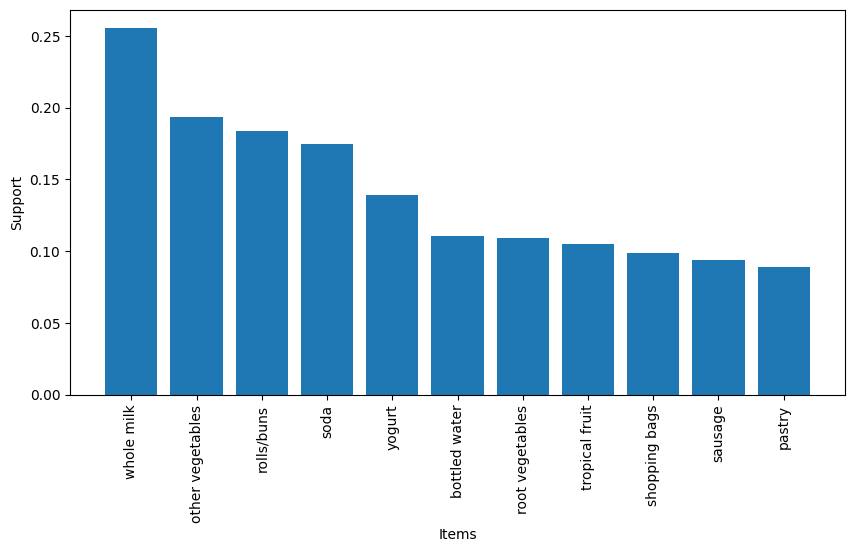

In [19]:
fig = plt.figure(figsize=(10,5))

plt.bar(popular_items.loc[0:10,'item'], popular_items.loc[0:10,'support'])
plt.xlabel('Items')
plt.xticks(rotation=90)
plt.ylabel('Support')
plt.show()

**for more information on visualization please see matplotlib official documentation pages**

**https://matplotlib.org/tutorials/index.html**

In [20]:
grocery.shape

(9835, 169)

In [21]:
grocery.head(2)

,frankfurter,sausage,liver loaf,ham,meat,finished products,organic sausage,chicken,turkey,pork,...,candles,light bulbs,sound storage medium,newspapers,photo/film,pot plants,flower soil/fertilizer,flower (seeds),shopping bags,bags
T0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
T1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Step 2. Short-list frequently occuring items/item sets by choosing a support level

**We will leverage the apriori algorithm which we imported to do this**

In [22]:
freq_items = apriori(grocery, min_support=0.01, use_colnames=True, max_len = None)
print (freq_items.shape)

/Volumes/SSD Workspace/tech_life/github/Data-Science-Adventures/.venv/lib/python3.7/site-packages/mlxtend/frequent_patterns/fpcommon.py:113: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  DeprecationWarning,


(333, 2)


In [23]:
freq_items.head()

,support,itemsets
0,0.058973,(frankfurter)
1,0.093950,(sausage)
2,0.026029,(ham)
3,0.025826,(meat)
4,0.042908,(chicken)


In [24]:
freq_items.tail()

,support,itemsets
328,0.011490,"(rolls/buns, yogurt, other vegetables)"
329,0.010066,"(whole milk, yogurt, curd)"
330,0.010880,"(whipped/sour cream, whole milk, yogurt)"
331,0.015557,"(whole milk, yogurt, rolls/buns)"
332,0.010473,"(whole milk, yogurt, soda)"


**The 20 most frequently occuring itemsets**

In [25]:
freq_items.sort_values('support', ascending=False).head(20)

,support,itemsets
18,0.255516,(whole milk)
16,0.193493,(other vegetables)
40,0.183935,(rolls/buns)
60,0.174377,(soda)
23,0.139502,(yogurt)
59,0.110524,(bottled water)
13,0.108998,(root vegetables)
9,0.104931,(tropical fruit)
87,0.098526,(shopping bags)
1,0.093950,(sausage)


## Step 3: From the frequently occuring item sets, generate association rules by choosing a metric

In [26]:
arules = association_rules(freq_items, metric='confidence', min_threshold= 0.3)
arules.shape

(125, 10)

In [27]:
arules.head(3)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(frankfurter),(whole milk),0.058973,0.255516,0.020539,0.348276,1.363029,0.005470,1.142330,0.283031
1,(frankfurter),(rolls/buns),0.058973,0.183935,0.019217,0.325862,1.771616,0.008370,1.210531,0.462839
2,(sausage),(whole milk),0.093950,0.255516,0.029893,0.318182,1.245252,0.005887,1.091910,0.217372


In [28]:
arules = arules.iloc[:,0:-2]
arules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage
0,(frankfurter),(whole milk),0.058973,0.255516,0.020539,0.348276,1.363029,0.005470
1,(frankfurter),(rolls/buns),0.058973,0.183935,0.019217,0.325862,1.771616,0.008370
2,(sausage),(whole milk),0.093950,0.255516,0.029893,0.318182,1.245252,0.005887
3,(sausage),(rolls/buns),0.093950,0.183935,0.030605,0.325758,1.771048,0.013324
4,(ham),(whole milk),0.026029,0.255516,0.011490,0.441406,1.727509,0.004839


In [29]:
arules.sort_values('lift', ascending=False).head(50)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage
74,"(citrus fruit, other vegetables)",(root vegetables),0.028876,0.108998,0.010371,0.359155,3.295045,0.007224
80,"(tropical fruit, other vegetables)",(root vegetables),0.035892,0.108998,0.012303,0.342776,3.144780,0.008391
9,(beef),(root vegetables),0.052466,0.108998,0.017387,0.331395,3.040367,0.011668
73,"(root vegetables, citrus fruit)",(other vegetables),0.017692,0.193493,0.010371,0.586207,3.029608,0.006948
79,"(root vegetables, tropical fruit)",(other vegetables),0.021047,0.193493,0.012303,0.584541,3.020999,0.008231
93,"(whole milk, other vegetables)",(root vegetables),0.074835,0.108998,0.023183,0.309783,2.842082,0.015026
119,"(whole milk, curd)",(yogurt),0.026131,0.139502,0.010066,0.385214,2.761356,0.006421
95,"(root vegetables, rolls/buns)",(other vegetables),0.024301,0.193493,0.012201,0.502092,2.594890,0.007499
94,"(root vegetables, yogurt)",(other vegetables),0.025826,0.193493,0.012913,0.500000,2.584078,0.007916
86,"(whole milk, tropical fruit)",(yogurt),0.042298,0.139502,0.015150,0.358173,2.567516,0.009249


**Lets say we want to see rules where at least two items appear in the antecedents**

In [30]:
arules['antlen'] = arules['antecedents'].str.len()
#arules['antlen'] = arules['antecedents'].apply(len) #same effect as above
arules.shape

(125, 9)

In [31]:
arules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,antlen
0,(frankfurter),(whole milk),0.058973,0.255516,0.020539,0.348276,1.363029,0.005470,1
1,(frankfurter),(rolls/buns),0.058973,0.183935,0.019217,0.325862,1.771616,0.008370,1
2,(sausage),(whole milk),0.093950,0.255516,0.029893,0.318182,1.245252,0.005887,1
3,(sausage),(rolls/buns),0.093950,0.183935,0.030605,0.325758,1.771048,0.013324,1
4,(ham),(whole milk),0.026029,0.255516,0.011490,0.441406,1.727509,0.004839,1


In [32]:
arules.loc[arules['antlen'] >= 2, :].head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,antlen
69,"(whole milk, sausage)",(other vegetables),0.029893,0.193493,0.010168,0.340136,1.757876,0.004384,2
70,"(sausage, other vegetables)",(whole milk),0.026945,0.255516,0.010168,0.377358,1.476849,0.003283,2
71,"(whole milk, pork)",(other vegetables),0.022166,0.193493,0.010168,0.458716,2.370714,0.005879,2
72,"(other vegetables, pork)",(whole milk),0.021657,0.255516,0.010168,0.469484,1.837394,0.004634,2
73,"(root vegetables, citrus fruit)",(other vegetables),0.017692,0.193493,0.010371,0.586207,3.029608,0.006948,2


**Filter rules with confidence < 0.5 and lift > 3**

In [33]:
arules.loc[(arules['confidence'] > 0.5) & (arules['lift'] > 3), :]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,antlen
73,"(root vegetables, citrus fruit)",(other vegetables),0.017692,0.193493,0.010371,0.586207,3.029608,0.006948,2
79,"(root vegetables, tropical fruit)",(other vegetables),0.021047,0.193493,0.012303,0.584541,3.020999,0.008231,2


In [34]:
arules.loc[(arules['support'] > 0.02 ) & (arules['lift'] > 2), :]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,antlen
23,(root vegetables),(other vegetables),0.108998,0.193493,0.047382,0.434701,2.246605,0.026291,1
33,(whipped/sour cream),(other vegetables),0.071683,0.193493,0.028876,0.402837,2.081924,0.015006,1
91,"(root vegetables, whole milk)",(other vegetables),0.048907,0.193493,0.023183,0.474012,2.449770,0.013719,2
93,"(whole milk, other vegetables)",(root vegetables),0.074835,0.108998,0.023183,0.309783,2.842082,0.015026,2
100,"(whole milk, yogurt)",(other vegetables),0.056024,0.193493,0.022267,0.397459,2.054131,0.011427,2
101,"(yogurt, other vegetables)",(whole milk),0.043416,0.255516,0.022267,0.512881,2.007235,0.011174,2


**Rules where an particular item is present or not in antecedents or consequents**

In [35]:
arules[arules['antecedents'] == {'curd'}]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,antlen
29,(curd),(other vegetables),0.053279,0.193493,0.017184,0.322519,1.666829,0.006874,1
41,(curd),(whole milk),0.053279,0.255516,0.026131,0.490458,1.919481,0.012517,1
67,(curd),(yogurt),0.053279,0.139502,0.017285,0.324427,2.325615,0.009853,1


In [36]:
arules[arules['antecedents'] == {'curd', 'yogurt'}]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,antlen
120,"(yogurt, curd)",(whole milk),0.017285,0.255516,0.010066,0.582353,2.279125,0.005649,2


In [37]:
arules[arules['consequents'] == {'whole milk'}].head(3)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,antlen
0,(frankfurter),(whole milk),0.058973,0.255516,0.020539,0.348276,1.363029,0.005470,1
2,(sausage),(whole milk),0.093950,0.255516,0.029893,0.318182,1.245252,0.005887,1
4,(ham),(whole milk),0.026029,0.255516,0.011490,0.441406,1.727509,0.004839,1


**Check if a particular item is present in a subset**

In [38]:
arules[arules['antecedents'].apply(lambda x: {'yogurt'} < x)]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,antlen
78,"(yogurt, citrus fruit)",(whole milk),0.021657,0.255516,0.010269,0.474178,1.855768,0.004736,2
84,"(yogurt, tropical fruit)",(other vegetables),0.029283,0.193493,0.012303,0.420139,2.171343,0.006637,2
87,"(yogurt, tropical fruit)",(whole milk),0.029283,0.255516,0.015150,0.517361,2.024770,0.007668,2
94,"(root vegetables, yogurt)",(other vegetables),0.025826,0.193493,0.012913,0.500000,2.584078,0.007916,2
96,"(root vegetables, yogurt)",(whole milk),0.025826,0.255516,0.014540,0.562992,2.203354,0.007941,2
100,"(whole milk, yogurt)",(other vegetables),0.056024,0.193493,0.022267,0.397459,2.054131,0.011427,2
101,"(yogurt, other vegetables)",(whole milk),0.043416,0.255516,0.022267,0.512881,2.007235,0.011174,2
116,"(whipped/sour cream, yogurt)",(other vegetables),0.020742,0.193493,0.010168,0.490196,2.533410,0.006154,2
118,"(rolls/buns, yogurt)",(other vegetables),0.034367,0.193493,0.011490,0.334320,1.727815,0.004840,2
120,"(yogurt, curd)",(whole milk),0.017285,0.255516,0.010066,0.582353,2.279125,0.005649,2


**Handld data that is not already in binominal format**

In [39]:
groc = pd.read_csv('grocery_dataset.txt', delimiter='\t', header=None)
groc.head(5)

,0
0,"citrus fruit,semi-finished bread,margarine,rea..."
1,"tropical fruit,yogurt,coffee"
2,whole milk
3,"pip fruit,yogurt,cream cheese ,meat spreads"
4,"other vegetables,whole milk,condensed milk,lon..."


In [40]:
#convert the dataset into a list of lists
groc_list = groc[0].apply(lambda x: x.split(',')).tolist()
groc_list

[['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups'],
 ['tropical fruit', 'yogurt', 'coffee'],
 ['whole milk'],
 ['pip fruit', 'yogurt', 'cream cheese ', 'meat spreads'],
 ['other vegetables',
  'whole milk',
  'condensed milk',
  'long life bakery product'],
 ['whole milk', 'butter', 'yogurt', 'rice', 'abrasive cleaner'],
 ['rolls/buns'],
 ['other vegetables',
  'UHT-milk',
  'rolls/buns',
  'bottled beer',
  'liquor (appetizer)'],
 ['pot plants'],
 ['whole milk', 'cereals'],
 ['tropical fruit',
  'other vegetables',
  'white bread',
  'bottled water',
  'chocolate'],
 ['citrus fruit',
  'tropical fruit',
  'whole milk',
  'butter',
  'curd',
  'yogurt',
  'flour',
  'bottled water',
  'dishes'],
 ['beef'],
 ['frankfurter', 'rolls/buns', 'soda'],
 ['chicken', 'tropical fruit'],
 ['butter', 'sugar', 'fruit/vegetable juice', 'newspapers'],
 ['fruit/vegetable juice'],
 ['packaged fruit/vegetables'],
 ['chocolate'],
 ['specialty bar'],
 ['other vegetables'],
 ['butter milk

In [41]:
#we can use mlxtend preprocessing function : TransactionEncoder

from mlxtend.preprocessing import TransactionEncoder
encoder = TransactionEncoder()
enc_trans = encoder.fit_transform(groc_list)
grocery_df2 = pd.DataFrame(enc_trans, columns=encoder.columns_)
grocery_df2.astype(int).head(3)

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
